## A Neural probabilistic language model
## Building makemore - Anderj Karpathy


In [1]:
import torch
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
random.seed(0)

%matplotlib inline
g = torch.Generator().manual_seed(0)

with open('../names.txt', 'r') as f:
    words = f.read().splitlines()
    
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [2]:
# define mapping from character to their numerical equivalent and back
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
# also add '.' as index 0
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

## In the original paper, sequence of words is represented in a constrained space called Table look-up

In this implementation, we use character level representation with a character size of 3. So, for all 3-digit characters of all words in the training data is represented in a smaller feature vector.

In [3]:
# build the dataset

block_size = 3 # context length

def build_dataset(words:list)->tuple:
    X, Y  =[], []
    for w in words[:5]:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context),'---->',itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])


In [4]:
# Cram 27 words in 2 dim space/embedding
# Each word is crammed into 2
C = torch.randn((27,2))
C

tensor([[-0.4174, -1.8522],
        [-0.0193,  0.6892],
        [ 0.7036, -1.2614],
        [-0.4384,  0.6185],
        [ 0.9893,  0.4588],
        [ 0.3879,  0.8541],
        [ 0.8773,  1.4420],
        [ 1.0467,  0.2953],
        [-0.0701, -2.1072],
        [ 1.2716,  0.3271],
        [-0.1983, -0.3868],
        [-0.7173,  1.1263],
        [-1.8349,  0.7585],
        [-0.3254, -0.3556],
        [ 0.5425,  0.8066],
        [-1.6192, -0.4541],
        [-0.1733, -1.5923],
        [ 1.0087, -1.8817],
        [ 1.2681, -0.4910],
        [-0.2180,  0.9391],
        [ 0.6543,  1.6556],
        [-0.9102,  1.4917],
        [-1.4713,  0.1643],
        [-0.9012,  1.0496],
        [-0.4350,  1.0116],
        [ 0.0651,  0.0889],
        [ 2.7538, -2.0988]])

In [71]:
# Create Multi-layer perceptron
C = torch.randn((27,10), generator=g)
W1 = torch.randn((30,200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [72]:
sum(p.nelement() for p in parameters)

11897

In [73]:
for p in parameters:
    p.requires_grad = True

In [74]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
lrs


tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [66]:
stepi = []

In [47]:
def find_lr(X_train, Y_train, C, W1, b1, W2, b2, parameters, lrs, iterations=1000, batch_size=32):

    lri = []
    lossi = []
    stepi = []
    for i in range(iterations):
        # Minibatch sampling
        ix = torch.randint(0, X_train.shape[0], (batch_size,))

        # Forward pass
        emb = C[X_train[ix]]  # (32, 3, 2)
        h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1)  # (32, hidden_dim)
        logits = h @ W2 + b2  # (32, output_dim)
        loss = F.cross_entropy(logits, Y_train[ix])

        print(f'Iteration {i}: Loss = {loss.item()}')

        # Zero gradients
        for p in parameters:
            p.grad = None
        loss.backward()

        # Update parameters with learning rate
        lr = lrs[i]
            
        for p in parameters:
            p.data += -lr * p.grad

        # Track stats
        lri.append(lr)
        stepi.append(i)
        lossi.append(loss.item())

    return lri, lossi, stepi


Iteration 0: Loss = 30.757869720458984
Iteration 1: Loss = 30.12940216064453
Iteration 2: Loss = 29.65835952758789
Iteration 3: Loss = 27.984272003173828
Iteration 4: Loss = 28.22953224182129
Iteration 5: Loss = 28.16730308532715
Iteration 6: Loss = 26.161972045898438
Iteration 7: Loss = 31.059314727783203
Iteration 8: Loss = 27.597347259521484
Iteration 9: Loss = 28.018659591674805
Iteration 10: Loss = 33.613433837890625
Iteration 11: Loss = 32.033912658691406
Iteration 12: Loss = 29.930173873901367
Iteration 13: Loss = 26.557018280029297
Iteration 14: Loss = 28.10740089416504
Iteration 15: Loss = 27.271133422851562
Iteration 16: Loss = 30.28089141845703
Iteration 17: Loss = 28.966856002807617
Iteration 18: Loss = 29.676898956298828
Iteration 19: Loss = 28.59687614440918
Iteration 20: Loss = 30.799365997314453
Iteration 21: Loss = 32.41954040527344
Iteration 22: Loss = 27.33424186706543
Iteration 23: Loss = 29.784160614013672
Iteration 24: Loss = 24.58415412902832
Iteration 25: Loss =

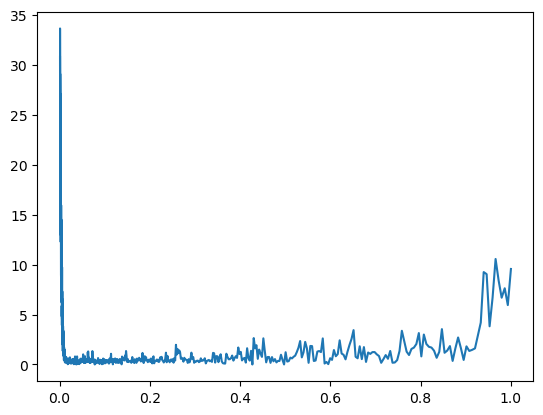

In [48]:
lri, lossi, stepi = find_lr(X_train, Y_train, C, W1, b1, W2, b2, parameters, lrs,len(lrs))
plt.plot(lri, lossi)

In [78]:
def train_model(X_train, Y_train, C, W1, b1, W2, b2, parameters, iterations=1000, batch_size=32):
    lossi = []
    stepi = []

    for i in range(iterations):
        # Minibatch sampling
        ix = torch.randint(0, X_train.shape[0], (batch_size,))

        # Forward pass
        emb = C[X_train[ix]]  # (32, 3, 2)
        h = torch.tanh(emb.view(-1, W1.shape[0]) @ W1 + b1)  # (32, hidden_dim)
        logits = h @ W2 + b2  # (32, output_dim)
        loss = F.cross_entropy(logits, Y_train[ix])

        print(f'Iteration {i}: Loss = {loss.item()}')

        # Zero gradients
        for p in parameters:
            p.grad = None
        loss.backward()

        # Update parameters with learning rate
        lr = 0.1 if i<100000 else 0.01
        for p in parameters:
            p.data += -lr * p.grad

        # Track stats
        stepi.append(i)
        lossi.append(loss.log10().item())
    return lossi, stepi

In [79]:
lossi, stepi = train_model(X_train=X_train, 
                                Y_train=Y_train, 
                                C=C, 
                                W1=W1, 
                                b1=b1, 
                                W2=W2, 
                                b2=b2, 
                                parameters=parameters, 
                                iterations=2000,
                                batch_size=32)

Iteration 0: Loss = 0.3661777377128601
Iteration 1: Loss = 0.19711944460868835
Iteration 2: Loss = 0.23068340122699738
Iteration 3: Loss = 0.21558932960033417
Iteration 4: Loss = 0.43483686447143555
Iteration 5: Loss = 0.20286080241203308
Iteration 6: Loss = 0.31205326318740845
Iteration 7: Loss = 0.2888234257698059
Iteration 8: Loss = 0.27529415488243103
Iteration 9: Loss = 0.23895442485809326
Iteration 10: Loss = 0.1742839813232422
Iteration 11: Loss = 0.4133862257003784
Iteration 12: Loss = 0.19638372957706451
Iteration 13: Loss = 0.4587979316711426
Iteration 14: Loss = 0.12381698191165924
Iteration 15: Loss = 0.3263261914253235
Iteration 16: Loss = 0.5037130117416382
Iteration 17: Loss = 0.5039221048355103
Iteration 18: Loss = 0.28821271657943726
Iteration 19: Loss = 0.2779475152492523
Iteration 20: Loss = 0.15720728039741516
Iteration 21: Loss = 0.14134912192821503
Iteration 22: Loss = 0.359156996011734
Iteration 23: Loss = 0.25245141983032227
Iteration 24: Loss = 0.10487414151430

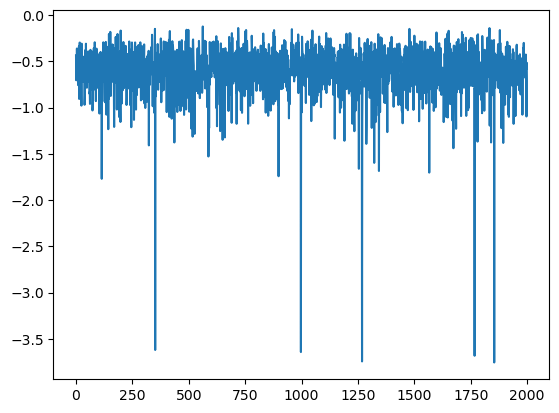

In [80]:
plt.plot(stepi, lossi)

## Loss of model

In [ ]:
# training loss


In [22]:
import torch.nn.functional as F

# number needs to be tensor for one-hot encoding
# data type of one hot is 64 bit int
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([0.0412, 0.0347])

In [23]:
# same as C[5]
C[5]

tensor([0.0412, 0.0347])

In [24]:
C[[5,6,7]]

tensor([[ 0.0412,  0.0347],
        [-2.0811, -0.2173],
        [-0.2252, -0.2435]])

In [27]:
C[torch.tensor([5,6,7,7,7])]

tensor([[ 0.0412,  0.0347],
        [-2.0811, -0.2173],
        [-0.2252, -0.2435],
        [-0.2252, -0.2435],
        [-0.2252, -0.2435]])

In [36]:
C[X]

tensor([[[-0.3707, -0.8815],
         [-0.3707, -0.8815],
         [-0.3707, -0.8815]],

        [[-0.3707, -0.8815],
         [-0.3707, -0.8815],
         [ 0.0412,  0.0347]],

        [[-0.3707, -0.8815],
         [ 0.0412,  0.0347],
         [-0.4614,  1.0634]],

        [[ 0.0412,  0.0347],
         [-0.4614,  1.0634],
         [-0.4614,  1.0634]],

        [[-0.4614,  1.0634],
         [-0.4614,  1.0634],
         [ 1.3642, -0.2655]],

        [[-0.3707, -0.8815],
         [-0.3707, -0.8815],
         [-0.3707, -0.8815]],

        [[-0.3707, -0.8815],
         [-0.3707, -0.8815],
         [-0.7650,  0.8279]],

        [[-0.3707, -0.8815],
         [-0.7650,  0.8279],
         [ 2.5173, -0.7549]],

        [[-0.7650,  0.8279],
         [ 2.5173, -0.7549],
         [ 1.9716,  0.7199]],

        [[ 2.5173, -0.7549],
         [ 1.9716,  0.7199],
         [ 1.7423,  1.4154]],

        [[ 1.9716,  0.7199],
         [ 1.7423,  1.4154],
         [ 1.9716,  0.7199]],

        [[ 1.7423,  1

In [37]:
C[X].shape

torch.Size([32, 3, 2])

In [41]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [40]:
# transform 32, 3,2 to 32, 6
emb = emb.view(32,6)
emb

tensor([[-0.3707, -0.8815, -0.3707, -0.8815, -0.3707, -0.8815],
        [-0.3707, -0.8815, -0.3707, -0.8815,  0.0412,  0.0347],
        [-0.3707, -0.8815,  0.0412,  0.0347, -0.4614,  1.0634],
        [ 0.0412,  0.0347, -0.4614,  1.0634, -0.4614,  1.0634],
        [-0.4614,  1.0634, -0.4614,  1.0634,  1.3642, -0.2655],
        [-0.3707, -0.8815, -0.3707, -0.8815, -0.3707, -0.8815],
        [-0.3707, -0.8815, -0.3707, -0.8815, -0.7650,  0.8279],
        [-0.3707, -0.8815, -0.7650,  0.8279,  2.5173, -0.7549],
        [-0.7650,  0.8279,  2.5173, -0.7549,  1.9716,  0.7199],
        [ 2.5173, -0.7549,  1.9716,  0.7199,  1.7423,  1.4154],
        [ 1.9716,  0.7199,  1.7423,  1.4154,  1.9716,  0.7199],
        [ 1.7423,  1.4154,  1.9716,  0.7199,  1.3642, -0.2655],
        [-0.3707, -0.8815, -0.3707, -0.8815, -0.3707, -0.8815],
        [-0.3707, -0.8815, -0.3707, -0.8815,  1.3642, -0.2655],
        [-0.3707, -0.8815,  1.3642, -0.2655,  1.7423,  1.4154],
        [ 1.3642, -0.2655,  1.7423,  1.4

In [47]:
emb.view(32,6)==torch.cat(torch.unbind(emb,1),1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [44]:
a =torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [45]:
a.view(2,9)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [46]:
# with view no memory is being changes/copied
# using storage offset, strides, shapes
# pytorch internals eric -->see
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [31]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [52]:
h = torch.tanh(emb.view(-1,6)@ W1+b1)

In [53]:
h

tensor([[ 0.1685, -0.9648,  0.7912,  ..., -0.3368, -0.9579,  0.9736],
        [-0.8998, -0.9325,  0.7118,  ...,  0.4657, -0.6647,  0.4029],
        [-0.9880, -0.8170, -0.5970,  ...,  0.2131,  0.6724, -0.9746],
        ...,
        [-0.7907,  0.9952, -0.9371,  ...,  0.9972,  0.9578, -1.0000],
        [-0.1385,  0.9966,  0.7227,  ...,  1.0000,  0.9859, -0.9970],
        [ 0.4763,  1.0000,  0.9993,  ...,  0.9677,  0.9914,  0.9866]])

In [54]:
# concatenation creates whole new tensor, storage so inefficiet
# broadcasting semantics
(emb.view(-1,6)@ W1).shape

torch.Size([32, 100])

In [55]:
b1.shape

torch.Size([100])

In [56]:
# boradcasting will align on right, create fake dimension 
# 32, 100 -> emb*w1
# 1,  100 ->b1

# then it will copy veritcally every element and add 

In [57]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [58]:

logits = h@W2+b2


In [59]:
logits.shape

torch.Size([32, 27])

In [60]:
counts = logits.exp()

In [61]:
prob = counts/counts.sum(1, keepdim=True)

In [62]:
prob.shape

torch.Size([32, 27])

In [63]:

torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [66]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(18.4067)

In [67]:
# use cross entopy because pytorch will not create new tensors in memory
# same as above implementations
# backward pass is much more efficient, runs in fused kernel??
# when logits take extreme values, like using exponential, you get nan
# you run out of dymaic range
# pytorch solves this with normalization (offset)
# pytorch calculates max value and substracts with max value, so no nan
F.cross_entropy(logits, Y)

tensor(18.4067)